In [1]:
import sys
sys.path.append("../")
import importlib
from functools import partial

import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_networkx

# import GNNInterpreter
# from GNNInterpreter.gnninterpreter import *
# importlib.reload(GNNInterpreter.gnninterpreter)

# import gnn_xai_common
# from gnn_xai_common import *
# importlib.reload(gnn_xai_common.trainer)

In [2]:
config = {
    "DATASET_NAME": "MUTAG", 
    "MAX_NODES": 20, 
    "device": "cuda"
}

# Data

In [3]:
import new_src.dataAdapter
from new_src.dataAdapter import load_dataset
importlib.reload(new_src.dataAdapter)

data = load_dataset(config.get("DATASET_NAME"))
cls_split = data.split_by_class()

# Explainee

In [4]:
import new_src.explainee
from new_src.explainee import fit_explainee
importlib.reload(new_src.explainee)

explainee, _ = fit_explainee(
    dataset_name = config.get("DATASET_NAME"),
    root="data",
    hidden=64,
    layers=3,
    dropout=0.2,
    epochs=10,
    batch_size=32,
    lr=1e-3,
    device=config.get("device")
)


# Extract embeddings. 
mean_embeds = [
    torch.cat([explainee(batch.to(config.get("device")))["embeds"]
               for batch in DataLoader(subset, batch_size=64)])
         .mean(dim=0)
    for subset in cls_split
]
mean_embeds = [m.detach() for m in mean_embeds]

[001/10] train_loss=0.6283  val_acc=0.789
[002/10] train_loss=0.5732  val_acc=0.789
[003/10] train_loss=0.5569  val_acc=0.789
[004/10] train_loss=0.5549  val_acc=0.789
[005/10] train_loss=0.5499  val_acc=0.789
[006/10] train_loss=0.5487  val_acc=0.789
[007/10] train_loss=0.5325  val_acc=0.842
[008/10] train_loss=0.5262  val_acc=0.842
[009/10] train_loss=0.5399  val_acc=0.842
[010/10] train_loss=0.5237  val_acc=0.842
Test Accuracy: 0.895


# GED Approximator

Generating synthetic GED dataset with 4 perturbations per graph...
Created GED dataset with 752 pairs.


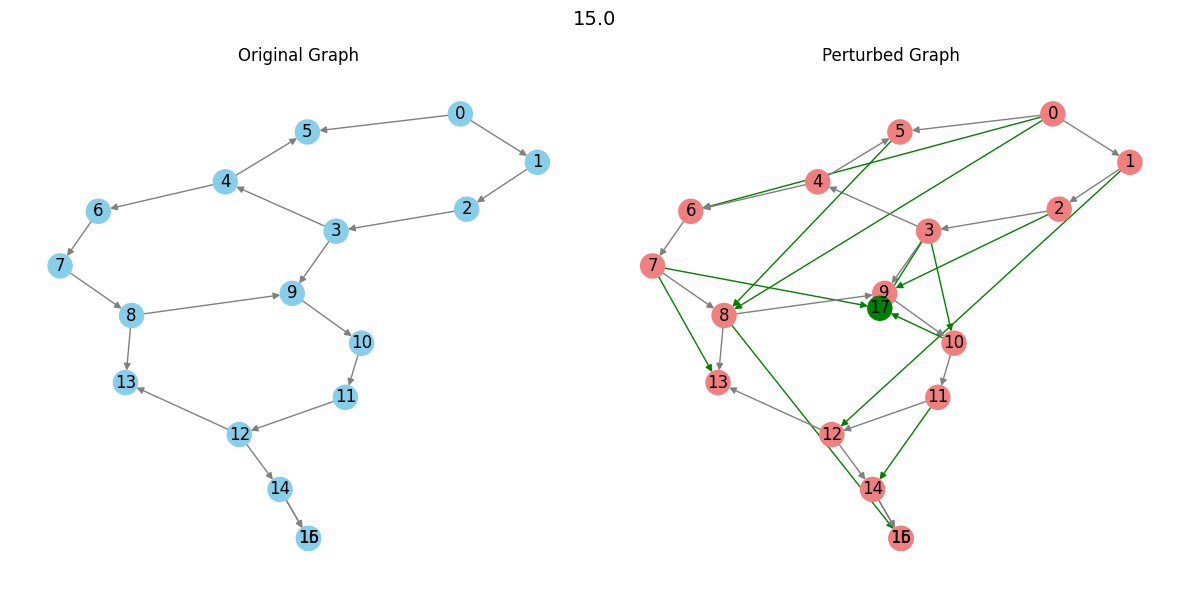

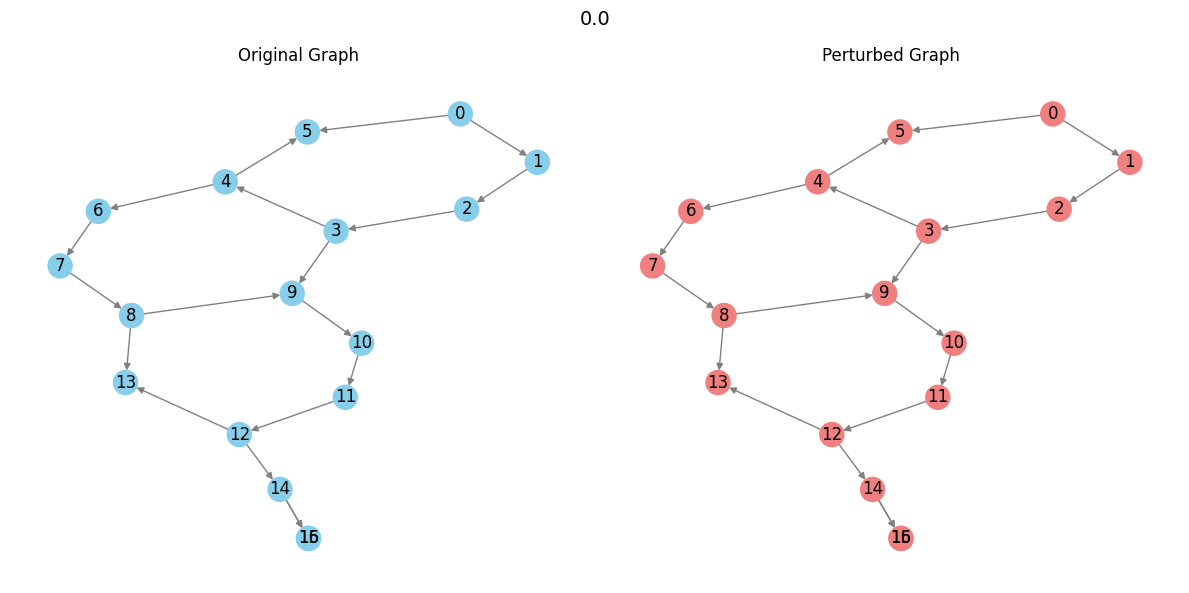

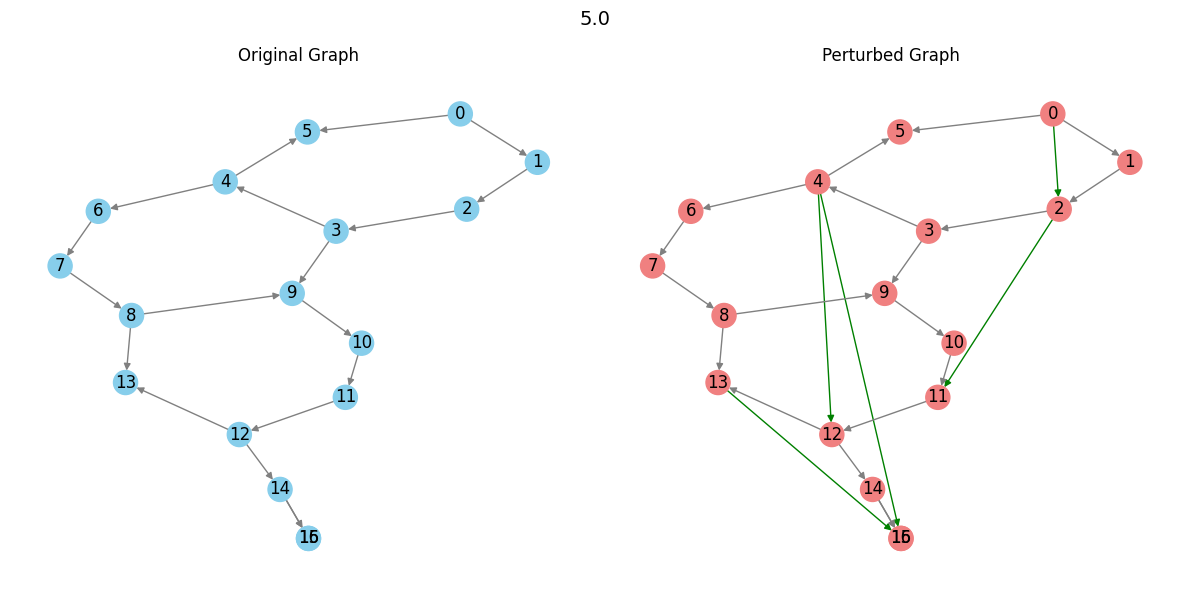

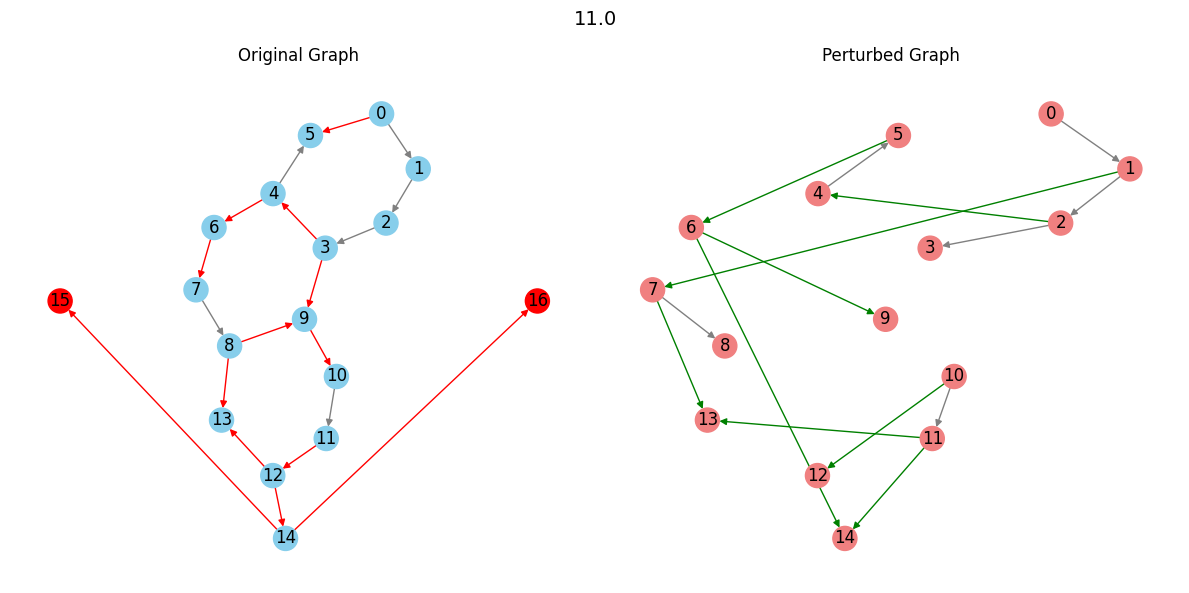

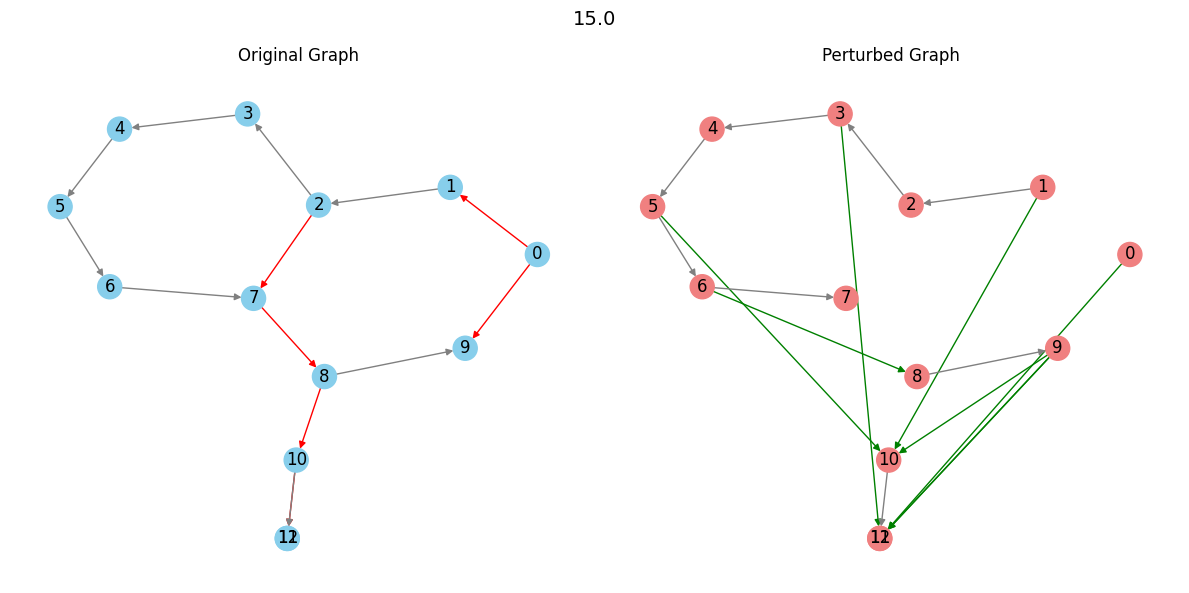

In [5]:
import new_src.ged_dataset
importlib.reload(new_src.ged_dataset)

from new_src.ged_dataset import create_and_save_ged_dataset, plot_graph_pair

ged_dataset = create_and_save_ged_dataset(
    data, 
    out_path=None, 
    n_perturbations=4,
    node_add_prob=0.5,
    node_remove_prob=0.5,
    edge_add_prob=0.1, 
    edge_remove_prob=0.1
)

print(f"Created GED dataset with {len(ged_dataset)} pairs.")

for i in range(5):
    g1, g2, ged_norm, _, _ = ged_dataset[i]
    raw_ged = getattr(g1, "raw_ged", ged_norm)
    plot_graph_pair(g1, g2, label=raw_ged)

In [6]:
import new_src.simgnn
importlib.reload(new_src.simgnn)

from new_src.simgnn import SimGNN, train_simgnn

model = SimGNN(in_dim=len(data.NODE_CLS))

train_simgnn(
    model=(m := model), 
    data=ged_dataset, 
    batch_size=64, 
    optimizer=(o := torch.optim.Adam(m.parameters(), lr=1e-3)),
    scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
    epochs=5, 
    device=config.get("device")
)

Training SimGNN:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 001 | Loss: 0.2053 | MSE(norm): 0.2053 | MSE(raw): 111.2728 | Corr(norm): 0.0707 | Corr(raw): 0.3443
Epoch 002 | Loss: 0.1298 | MSE(norm): 0.1298 | MSE(raw): 55.4724 | Corr(norm): 0.2867 | Corr(raw): 0.6266
Epoch 003 | Loss: 0.1197 | MSE(norm): 0.1197 | MSE(raw): 52.1428 | Corr(norm): 0.3070 | Corr(raw): 0.6122
Epoch 004 | Loss: 0.1144 | MSE(norm): 0.1144 | MSE(raw): 48.4345 | Corr(norm): 0.3601 | Corr(raw): 0.6620
Epoch 005 | Loss: 0.1149 | MSE(norm): 0.1149 | MSE(raw): 47.2277 | Corr(norm): 0.3924 | Corr(raw): 0.6791


# Distances

In [7]:
import new_src.graph_level_dist
importlib.reload(new_src.graph_level_dist)

from new_src.graph_level_dist import (
    neural_approx_ged_dist, 
    mcs_soft_graph_dist, 
    spectral_dist, 
    wl_graph_kernel_dist
)

nn_GED = neural_approx_ged_dist(
    data, model
)

max_common_sub = mcs_soft_graph_dist(
    data
)

spectral_dist = spectral_dist(
    data
) 

wl_graph_kernel_dist = wl_graph_kernel_dist(
    data
)

# Generator

In [13]:
from functools import partial
from new_src.ray_train_module import train_generator as ray_train_generator

GEN_MAX_NODES = config.get("MAX_NODES")
GEN_DEVICE = config.get("device")

train_generator = partial(
    ray_train_generator,
    data=data,
    mean_embeds=mean_embeds,
    explainee=explainee,
    nn_ged=nn_GED,
    max_common_sub=max_common_sub,
    spectral_dist_fn=spectral_dist,
    wl_graph_kernel_dist_fn=wl_graph_kernel_dist,
    max_nodes=GEN_MAX_NODES,
    device=GEN_DEVICE,
)


In [14]:
gen_samples = 2

graphs_0 = []
graphs_1 = []
for i in range(gen_samples): 
    graphs_0.append(train_generator(0, data, mean_embeds, explainee))
    graphs_1.append(train_generator(1, data, mean_embeds, explainee))

  0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Tuning

# Evaluation

In [31]:
import new_src.eval 
importlib.reload(new_src.eval)

from new_src.eval import eval_summary

dist_to_0 = neural_approx_ged_dist(cls_split[0], model)
dist_to_1 = neural_approx_ged_dist(cls_split[1], model)

score = eval_summary(
    explainee, 
    graphs_0,
    graphs_1, 
    cls_split[0], 
    cls_split[1], 
    dist_to_0, 
    dist_to_1
)

Prediction Interval Class 0 0.5777021646499634 +/- 0.0675801932811737

Prediction Interval Class 1 0.6511427760124207 +/- 0.07875591516494751

Counterfactual Shift to Class 0 0.053251441568136215 +/- 0.07115040719509125

Counterfactual Shift to Class 1 0.1462801992893219 +/- 0.06368795782327652

Class 0 Perturbation Sensitivity 0.03029913641512394 +/- 0.02789614163339138

Class 1 Perturbation Sensitivity 0.014058858156204224 +/- 0.010872846469283104

Relative Distance to Class 0 -0.24734856188297272 +/- 0.09956027567386627 

Relative Distance to Class 1 -0.04173281788825989 +/- 0.026247531175613403 



## Ray Tune Hyperparameter Optimization

Leverage Ray Tune to optimize the generator loss weights prior to final result reporting.


In [ ]:
import ray

ray.shutdown()
ray.init(num_gpus=1, runtime_env={"py_modules": ["/repo/revisions/new_src"]})


### Share large objects with Ray workers

Store dataset artifacts in the object store so Ray Tune trials avoid serializing heavy Python objects.


In [ ]:
explainee_ref = ray.put(explainee)
data_ref = ray.put(data)
mean_embeds_ref = ray.put(mean_embeds)
dist_to_0_ref = ray.put(neural_approx_ged_dist(cls_split[0], model))
dist_to_1_ref = ray.put(neural_approx_ged_dist(cls_split[1], model))
nn_ged_ref = ray.put(nn_GED)
max_common_sub_ref = ray.put(max_common_sub)
spectral_dist_ref = ray.put(spectral_dist)
wl_graph_kernel_dist_ref = ray.put(wl_graph_kernel_dist)


### Define the Ray Tune trainable

Wrap generator training and evaluation in a Ray-compatible trainable with explicit dependencies.


In [ ]:
def tune_trainable(config, *, explainee_ref, data_ref, mean_embeds_ref, dist_to_0_ref, dist_to_1_ref, gen_samples=2):
    import ray
    from ray import tune
    from new_src.eval import eval_summary
    from new_src.ray_train_module import train_generator as ray_train_generator

    explainee = ray.get(explainee_ref)
    data = ray.get(data_ref)
    mean_embeds = ray.get(mean_embeds_ref)
    dist_to_0 = ray.get(dist_to_0_ref)
    dist_to_1 = ray.get(dist_to_1_ref)

    nn_ged = ray.get(nn_ged_ref)
    max_common_sub = ray.get(max_common_sub_ref)
    spectral_dist_fn = ray.get(spectral_dist_ref)
    wl_graph_kernel_dist_fn = ray.get(wl_graph_kernel_dist_ref)

    cls_split = data.split_by_class()

    pred_weight = config["pred_weight"]
    embed_weight = config["embed_weight"]
    ged_weight = config["ged_weight"]
    mcs_weight = config["mcs_weight"]
    spectral_weight = config["spectral_weight"]
    wl_weight = config["wl_weight"]

    graphs_0 = []
    graphs_1 = []
    for _ in range(gen_samples):
        graphs_0.append(
            ray_train_generator(
                0,
                data=data,
                mean_embeds=mean_embeds,
                explainee=explainee,
                nn_ged=nn_ged,
                max_common_sub=max_common_sub,
                spectral_dist_fn=spectral_dist_fn,
                wl_graph_kernel_dist_fn=wl_graph_kernel_dist_fn,
                max_nodes=GEN_MAX_NODES,
                device=GEN_DEVICE,
                w_pred=pred_weight,
                w_embed=embed_weight,
                w_ged=ged_weight,
                w_msc=mcs_weight,
                w_spec=spectral_weight,
                w_wl=wl_weight,
            )
        )
        graphs_1.append(
            ray_train_generator(
                1,
                data=data,
                mean_embeds=mean_embeds,
                explainee=explainee,
                nn_ged=nn_ged,
                max_common_sub=max_common_sub,
                spectral_dist_fn=spectral_dist_fn,
                wl_graph_kernel_dist_fn=wl_graph_kernel_dist_fn,
                max_nodes=GEN_MAX_NODES,
                device=GEN_DEVICE,
                w_pred=pred_weight,
                w_embed=embed_weight,
                w_ged=ged_weight,
                w_msc=mcs_weight,
                w_spec=spectral_weight,
                w_wl=wl_weight,
            )
        )

    score = eval_summary(
        explainee,
        graphs_0,
        graphs_1,
        cls_split[0],
        cls_split[1],
        dist_to_0,
        dist_to_1,
    )

    tune.report(score=float(score))


### Configure the search space

Sample generator loss weights uniformly over the specified ranges.


In [ ]:
from ray import tune

search_space = {
    "pred_weight": tune.uniform(0, 50),
    "embed_weight": tune.uniform(0, 50),
    "ged_weight": tune.uniform(0, 50),
    "mcs_weight": tune.uniform(0, 50),
    "spectral_weight": tune.uniform(0, 50),
    "wl_weight": tune.uniform(0, 50),
}


### Launch the Ray Tune search

Attach shared parameters and execute the weighted generator search.


In [ ]:
t_trainable = tune.with_parameters(
    tune_trainable,
    explainee_ref=explainee_ref,
    data_ref=data_ref,
    mean_embeds_ref=mean_embeds_ref,
    dist_to_0_ref=dist_to_0_ref,
    dist_to_1_ref=dist_to_1_ref,
)

t_trainable = tune.with_resources(t_trainable, {"cpu": 1, "gpu": 1})

tuner = tune.Tuner(
    t_trainable,
    param_space=search_space,
    tune_config=tune.TuneConfig(metric="score", mode="max", num_samples=20),
)
results = tuner.fit()
results


### Review tuning outcomes

Inspect the best configuration and visualize trial performance.


In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display

best_config = results.get_best_result().config
print("Best configuration:", best_config)

df = results.get_dataframe()
display(df)

df_sorted = df.reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(df_sorted.index.to_numpy(), df_sorted["score"].to_numpy(), marker="o")
plt.xlabel("Trial")
plt.ylabel("score")
plt.title("Ray Tune score across trials")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


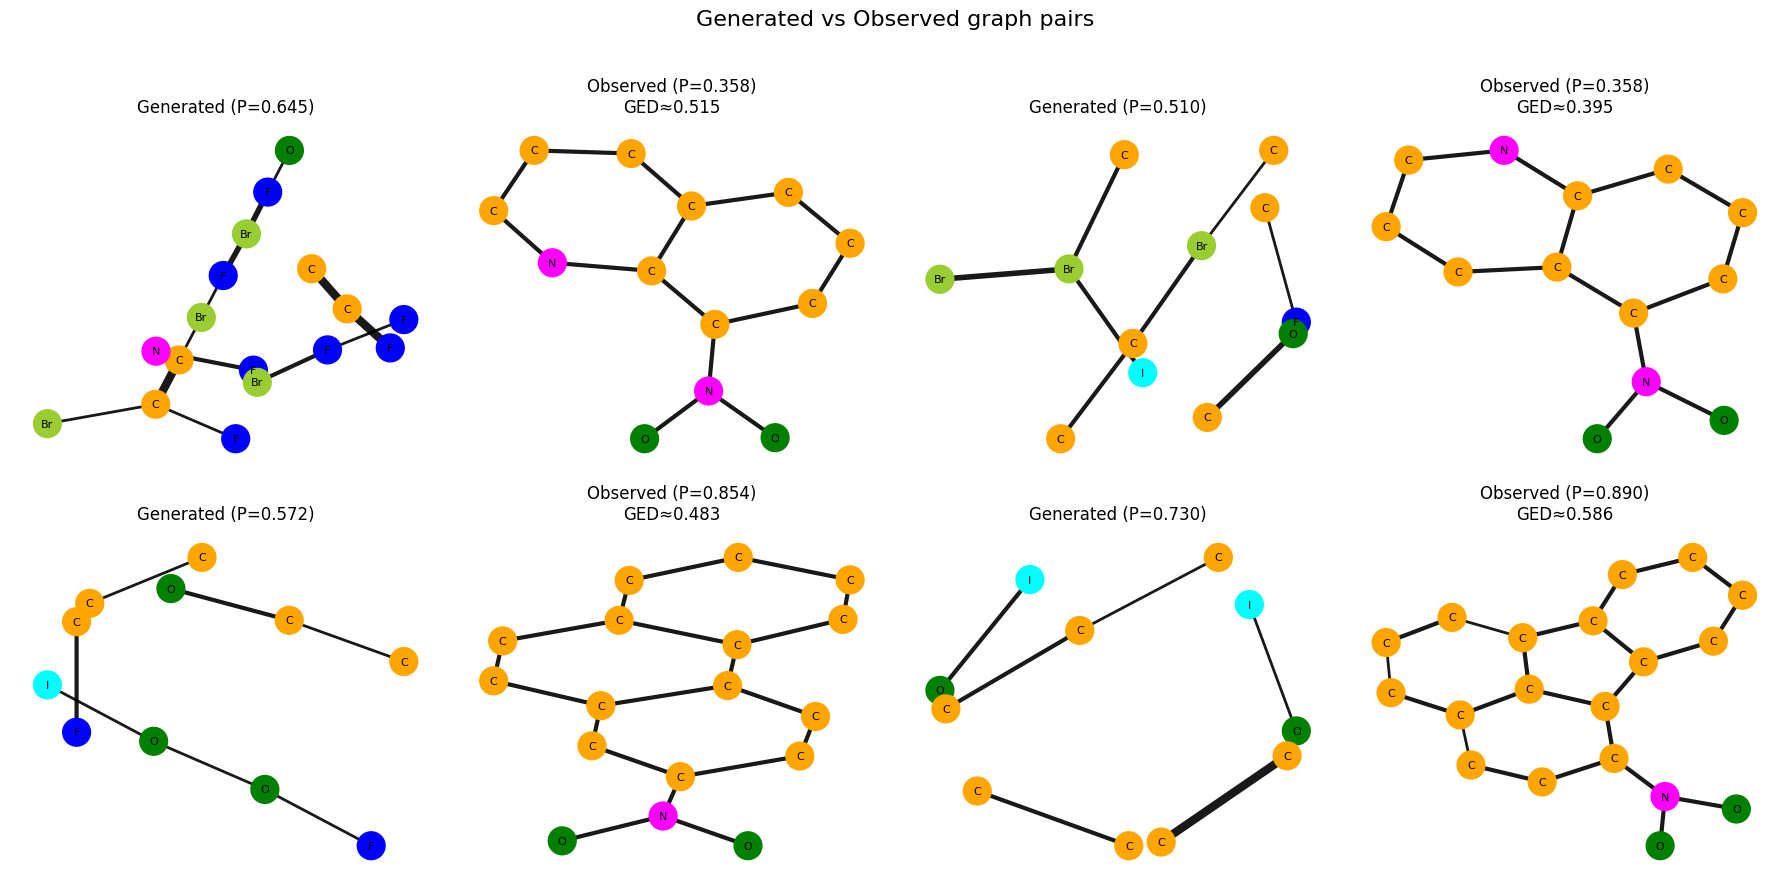

In [27]:
import new_src.utils
importlib.reload(new_src.utils)

from new_src.utils import eval_plot 

eval_plot(
    explainee, 
    graphs_0, 
    graphs_1, 
    obs_graphs_0=cls_split[0], 
    obs_graphs_1=cls_split[1],
    ged_model=model, 
    dataset=data,
    layout="kamada"
)

# GNNInterpreter